# day18: Introduction to automatic differentiation for gradient descent


# Objectives

We will practice:

* Using the **Pytorch** Python package to compute gradients of functions ("automatic differentiation")
* Using gradients from Pytorch to do a basic linear regression

# Outline

* [Part 1: Pytorch for univariate derivatives](#part1)
* [Part 2: Pytorch for multiple parameters](#part2)
* [Part 3: Using CUDA and where autodiff fails](#part3)
* [Part 4: Using Pytorch to solve linear regression](#part4)
* [Part 5: Pytorch's NN library and building neural networks](#part5)


In [ ]:
import torch

In [ ]:
# Import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

<a name="part1"></a>

# PART 1: Pytorch for univariate derivatives

Pytorch has a very `numpy`-like API that allows us to perform math operations on **tensors** (which is a fancy way of saying high-dimensional arrays). a `torch.tensor` is basically a `numpy.array` with some extra functionality.

Let's start by creating a tensor with a single value, and we'll mark it's `requires_grad` as `True` to indicate we will want derivatives with respect to it.

In [ ]:
z = torch.tensor(7.0, requires_grad=True)

Let's do simple some simple arithmetic:

In [ ]:
loss = z ** 2
loss

tensor(49., grad_fn=<PowBackward0>)

This is interesting. I was expecting to see 49, but not the `grad_fn`. What's happening behind the scenes is that Pytorch is constructing the **computation graph** for your arithmetic, so that later you can backpropagate through those operations. `loss` contains a pointer to its parent (`z`) in the computation graph, as well as a function for how to compute the derivative.

To launch backpropagation, you need to call `loss.backward()`:

In [ ]:
loss = z ** 2
loss.backward()

When you do this, you're asking Pytorch to compute the derivative of the loss with respect to every tensor with `requires_grad=True`. In this case, the only relevant tensor is `z`, so it'll compute the derivative of the loss with respect to `z`. It computes this derivative by walking backwards through the computation graph (i.e. the backpropagation algorithm).

Once it's computed $\frac{\partial J}{\partial z},$ it puts the result into `z.grad`.

In [ ]:
# what do we expect to see?
# z.grad

### Quick checks:
- Does the answer look correct to you?
- What happens when you run the "compute loss and backward" cell above multiple times? Check z.grad.
- What happens if we didn't set `z.requires_grad = True`? Rerun the cells above with that change.
  

In [ ]:
# NOTE when you want to reset z.grad, you can do so with this:
z.grad = None

### How is the derivative computed?

Pytorch does **not** use numerical approximations (e.g. estimating derivatives by perturbing inputs) and it does **not** do symbolic math. Instead, it just applies the backpropagation algorithm: the chain rule and the additivity rule.

In [ ]:
z = torch.tensor(7.0, requires_grad=True)
loss = 2 ** (1/torch.log(z)) - z ** 2
loss.backward()
z.grad

tensor(-14.0373)

Pytorch knows the derivative of each elementary operation, e.g. $2^x, x^2, 1/x, \log(x)$ and can compute and combine these derivatives to find the overall derivative.

### Example Use Case: Constant Predictor

This is helpful for implementing gradient descent!

Let's generate a random dataset of elephant weights

In [ ]:
torch.manual_seed(47)
y = torch.randn(50) * 1000 + 4123
y

tensor([4322.2104, 3829.7019, 3767.7952, 5682.5039, 4012.3584, 3945.4619,
        5894.3818, 3390.1843, 4386.3022, 4251.0361, 3057.7227, 2804.7231,
        5392.6113, 5903.7949, 6197.0273, 4306.3970, 3876.6248, 4099.7202,
        4593.9111, 4260.9360, 5274.7778, 4424.7178, 3561.7102, 4162.0928,
        5755.1719, 3856.8628, 3831.2681, 5133.7056, 4571.1260, 5416.7280,
        4175.2256, 3286.0952, 3569.0374, 3955.3115, 3534.4600, 4148.4648,
        2914.6543, 4408.6479, 4858.1582, 3499.4670, 3960.7537, 4505.9287,
        4240.3076, 4096.3604, 4622.2563, 3368.0278, 4864.7896, 5693.3867,
        3415.4487, 3430.2424])

Now let's try to find the optimal "constant predictor" model, the value of `b` for which
$$\frac{1}{50}\sum_{i=1}^{50} (b - y_i)^2$$
is minimized. We already know from class the answer will be the mean, but let's try to find it without any math by hand.

In [ ]:
b = torch.tensor(0., requires_grad=True)
loss = torch.mean((b - y)**2)
print("Loss:")
print(loss)

loss.backward()
print("Derivative:")
print(b.grad)

Loss:
tensor(19079782., grad_fn=<MeanBackward0>)
Derivative:
tensor(-8580.4238)


Now we should update the value of `b` with this derivative:

In [ ]:
alpha = 0.01 # learning rate/step size

# What's wrong with this line of code?
b = b - alpha * b.grad
b

tensor(85.8042, grad_fn=<SubBackward0>)

Implementing gradient descent:

In [ ]:
b = torch.tensor(0., requires_grad=True)
alpha = 0.01

for t in range(1000):
    loss = torch.mean((b - y)**2)
    loss.backward()
    b.data = b.data - alpha * b.grad
    b.grad = None

In [ ]:
print("True mean:")
print(y.mean())
print("Learned param:")
print(b)

True mean:
tensor(4290.2119)
Learned param:
tensor(4290.1997, requires_grad=True)


### Quick checks:
- Why do we need to reference `b.data` in the gradient update step? Why not just `b`?
- Why are we computing the loss over and over again? Can we skip that line and just call `loss.backward()` repeatedly?
- Why do we need to set `b.grad = None` every time?

<a id="part2"></a>

# PART 2: Pytorch for multiple parameters

I mentioned before that `loss.backward()` will propagate derivatives to **every** input with `requires_grad=True`. Let's consider a simple regression example:

In [ ]:
x = torch.tensor([1.,2.,3.])
w = torch.tensor([3.,4.,5.])
b = torch.tensor(7.)
y = torch.tensor(6.)

loss = (x.dot(w) + b - y) ** 2

### Quick check:
- Which values above should have `requires_grad=True`?
- Add `requires_grad` to those variables and call `loss.backward()`. Do you see the result you would expect?

Let's try a more complicated neural network! Let's say we have a few layers

In [ ]:
x = torch.tensor([1.,2.,3.]) # input data


torch.manual_seed(4747) # generate random parameters for initialization
W1 = torch.randn(3,3)
b1 = torch.randn(3)

W2 = torch.randn(3,3)
b2 = torch.randn(3)

w_out = torch.randn(3,3)
b_out = torch.randn(3)

loss = ... # TODO write the forward pass of the function, then call loss.backward()
           # use torch.sigmoid() as your activation function.

The power of automatic differentiation is that it lets you write custom loss functions! You can write anything you want and compute gradients, then use those gradients to update your model and iterate.

<a id="part3"></a>

# PART 3: Using CUDA, and where autodiff fails



If you are in Colab, you should be able to go to Runtime > Change Runtime Type and select a GPU. If you have a GPU available, the following line of code will return `True`:

In [ ]:
torch.cuda.is_available()

False

GPUs are excellent at computing things in parallel, and matrix multiplication requires a lot of parallel computation! The homework will demonstrate just how important the speedup is. If cuda is available, you need to send **all** tensors you're working with to the GPU (via NVIDIA's "cuda" framework) so that the computation happens there.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x = torch.tensor([1.,2.,3.]).to(device)
w = torch.tensor([3.,4.,5.]).to(device)
b = torch.tensor(7.).to(device)
y = torch.tensor(6.).to(device)

loss = (x.dot(w) + b - y) ** 2

**How Autodiff can fail v1: in-place operations**

Try running the below cell (including the backward call). Why does it break?

In [ ]:
z = torch.ones(100, requires_grad=True)
v = torch.sigmoid(z)
v[50] = 100
loss = v.sum()
# loss.backward()

**How Autodiff can fail v2: ALSO in-place operations**

Consider the two (theoretically) equivalent blocks of code. Why do they allocate such different amounts of memory?

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
baseline_memory = torch.cuda.memory_allocated()

In [ ]:
z = torch.ones(1000, requires_grad=True).to(device)
v = torch.sigmoid(z)
torch.cuda.memory_allocated() - baseline_memory

0

In [ ]:
del z
del v
torch.cuda.memory_allocated() - baseline_memory

0

In [ ]:
z = torch.ones(1000, requires_grad=True).to(device)
v = torch.zeros_like(z)
for i in range(1000):
    v[i] = torch.sigmoid(z[i])

In [ ]:
torch.cuda.memory_allocated() - baseline_memory

0

### TIPS:
- Remember that Pytorch needs to keep a full "history" of everything computed in the forward pass. You don't want to mess up that history!
- You should almost never be editing individual entries of a tensor: it will copy the entire tensor to maintain the history.
- `torch.stack` is a reasonable alternative. e.g. running
```
v = torch.stack([z + 3., z + 4.])
```
is much better than running
```
v = torch.zeros(2)
v[0] = z + 3.
v[1] = z + 4.
```

# PART 4: Pytorch for Gradient Descent

### Helper function: basic gradient descent

Here's a very simple function that will perform many gradient descent steps to optimize a given function.



In [ ]:
def run_many_iters_of_gradient_descent(
    fwd_func, init_theta_G=None, n_iters=100, step_size=0.001):
    ''' Run many iterations of GD

    Args
    ----
    fwd_func : python function (G,) to float
               Maps vector theta_G to scalar loss
    init_theta_G : 1D array, shape (G,)
        Initial value for the input vector (parameters)
    n_iters : int
        Number of gradient descent update steps to perform
    step_size : positive float
        Step size or learning rate for GD

    Returns
    -------
    theta_G : 1D array, shape (G,)
        Best value of input vector for provided loss f found via this GD procedure
    history : dict
        Contains history of this GD run useful for plotting diagnostics
    '''
    # Copy the initial parameter vector
    theta_G = init_theta_G.clone()
    theta_G.requires_grad = True

    # Create data structs to track the per-iteration history of different quantities
    history = dict(
        iter=[],
        f=[],
        theta_G=[],
        grad_G=[])

    for iter_id in range(n_iters):
        loss = fwd_func(theta_G)
        loss.backward()

        history['iter'].append(iter_id)
        history['f'].append(loss.item())
        history['theta_G'].append(theta_G.clone())
        history['grad_G'].append(theta_G.grad)

        if iter_id < n_iters - 1: # skip update the last time
            theta_G.data = theta_G.data - step_size * theta_G.grad

        theta_G.grad = None

    return theta_G, history

We observe $N$ examples $(x_n, y_n)$ consisting of D-dimensional 'input' vectors $x_n$ and scalar outputs $y_n$.

Consider the multivariate linear regression model for making a prediction given any input vector $x_i \in \mathbb{R}^D$:

\begin{align}
\hat{y}(x_i) = w^T x_i
\end{align}

One way to train weights would be to just compute the weights that minimize mean squared error

\begin{align}
\min_{w \in \mathbb{R}^D}  \sum_{n=1}^N (y_n - x_n^T w )^2
\end{align}


### Toy Data for linear regression task

We'll generate data that comes from an idealized linear regression model.

Each example has D=2 dimensions for x.

* The first dimension is weighted by +4.2.

* The second dimension is weighted by -4.2

The true intercept/bias is 0.1

In [ ]:
import numpy as np
import pandas as pd

torch.manual_seed(47)

N = 100
D = 2
sigma = 0.1

true_w_D = torch.tensor([4.2, -4.2])
true_bias = 0.1


x_NF = (torch.rand((N,D)) - 0.5) * 10
y_N = x_NF.matmul(true_w_D) + true_bias + sigma * torch.randn(N)

true_theta_G = torch.tensor([0.1, 4.2, -4.2])

### Toy Data Visualization: Pairplots for all possible (x_d, y) combinations

You can clearly see the slopes of the lines:
* x1 vs y plot: slope is around +4
* x2 vs y plot: slope is around -4

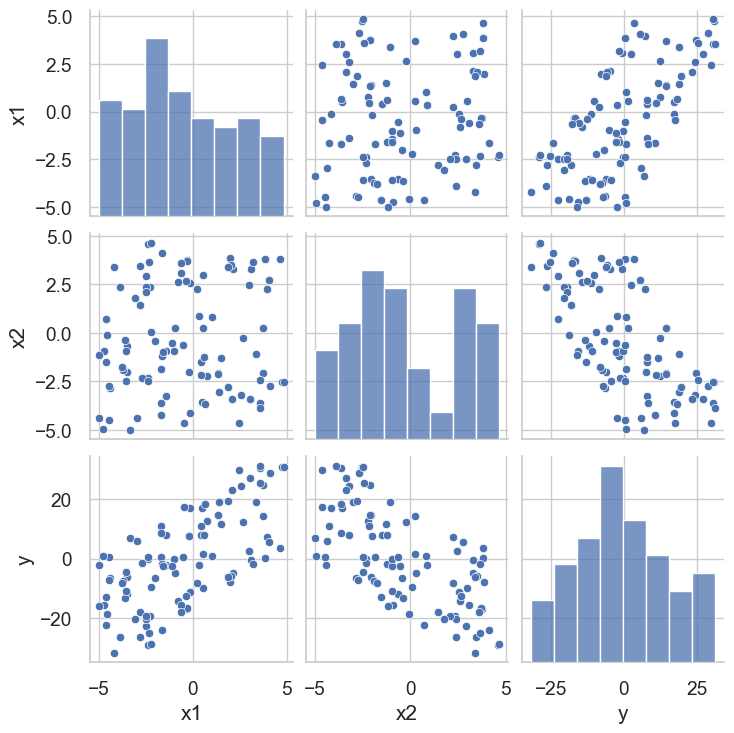

In [ ]:
sns.pairplot(
    data=pd.DataFrame(np.hstack([x_NF, y_N[:,np.newaxis]]), columns=['x1', 'x2', 'y']));

In [ ]:
# Add a column of 1s to x_NF
xtilde_NG = torch.hstack([torch.ones(100,1), x_NF])

# Define the loss-computing function
def calc_mse_loss(theta_G):
    return torch.mean((xtilde_NG.matmul(theta_G) - y_N)**2)

In [ ]:
# Test the *loss function* at the known "ideal" initial point

calc_mse_loss(true_theta_G)

tensor(0.0116)

In [ ]:
# Createa an all-zero parameter vector to use as our initial guess

init_theta_G = torch.zeros(3)

In [ ]:
# Test the *loss function* at that all-zero initial point

calc_mse_loss(init_theta_G)

tensor(248.8041)

### Run gradient descent

Use the code below to run GD on our simple regression problem

In [ ]:
# Because the gradient's magnitude is large, use a small step size
opt_theta_G, history = run_many_iters_of_gradient_descent(
    calc_mse_loss, init_theta_G,
    n_iters=400, step_size=0.001,
    )

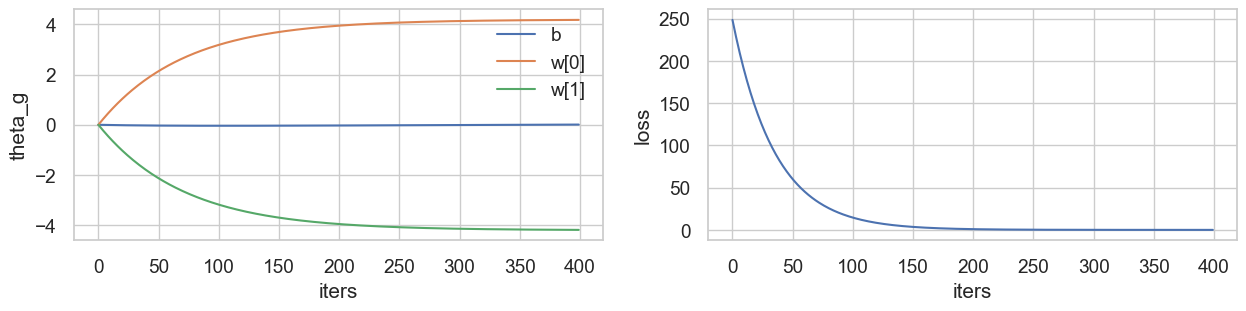

In [ ]:
# Make plots of how parameter values evolve over iterations, and function values evolve over iterations

fig_h, subplot_grid = plt.subplots(
    nrows=1, ncols=2, sharex=True, sharey=False, figsize=(15,3), squeeze=False)

with torch.no_grad():
    subplot_grid[0,0].plot(history['iter'], np.vstack(history['theta_G'])[:,0], label='b');

    for d in range(D):
        subplot_grid[0,0].plot(history['iter'], np.vstack(history['theta_G'])[:,d+1], label='w[%d]' % d);
    subplot_grid[0,0].set_xlabel('iters')
    subplot_grid[0,0].set_ylabel('theta_g')
    subplot_grid[0,0].legend(loc='upper right')

    subplot_grid[0,1].plot(history['iter'], history['f'])
    subplot_grid[0,1].set_xlabel('iters')
    subplot_grid[0,1].set_ylabel('loss');

### Check-in:
- Do these trace plots indicate we have converged to good weight vector values? Why or why not?
- In the gradient descent code, `loss.item()` takes the value of the loss while throwing away all of the Pytorch bells and whistles. Why would it be a bad idea to omit this and keep storing all attributes of each `loss` object?

Memory issues get significantly more important when you're running on GPUs, as they have very limited memory!

<a id="part5"></a>

# Part 5: Pytorch's NN library and building neural networks

How does all of this look "in the wild", where people use Pytorch to build custom neural networks with custom loss functions?

First, you wrap all of your parameters in a Pytorch class!

In [ ]:
from torch import nn
import torch.optim
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class MLP(nn.Module):

    def __init__(self, device):
        super(MLP, self).__init__()

        self.linear_layer1 = nn.Linear(3, 8)
        self.linear_layer2 = nn.Linear(8, 8)
        self.linear_layer3 = nn.Linear(8,1)
        self.activation = nn.ReLU()

        self.to(device) # send ALL parameters to the specified device

    def forward(self, x):
        z1 = self.linear_layer1(x)
        u1 = self.activation(z1)
        z2 = self.linear_layer2(u1)
        u2 = self.activation(z2)
        return self.linear_layer3(u2)[...,0]

mlp = MLP(device)
print(mlp)

MLP(
  (linear_layer1): Linear(in_features=3, out_features=8, bias=True)
  (linear_layer2): Linear(in_features=8, out_features=8, bias=True)
  (linear_layer3): Linear(in_features=8, out_features=1, bias=True)
  (activation): ReLU()
)


When you construct layers in the `init` function, Pytorch has a default method for initializing the value of all parameters:

In [ ]:
mlp.linear_layer1.weight

Parameter containing:
tensor([[-0.0638, -0.0095,  0.1888],
        [ 0.5537,  0.1475, -0.3666],
        [ 0.5317, -0.5671, -0.4455],
        [-0.2348, -0.2130, -0.1158],
        [-0.2152,  0.0515,  0.0121],
        [-0.5264, -0.4538, -0.0384],
        [-0.1019,  0.3728, -0.1439],
        [-0.0084,  0.4924, -0.1773]], requires_grad=True)

You can call the forward function by calling `mlp.forward(x)` or just `mlp(x)`

In [ ]:
torch.manual_seed(47)
x_NF = torch.randn(1000,3).to(device) # 1000 data points, 3 columns
y_N = torch.randn(1000).to(device)

loss = torch.mean((mlp(x_NF) - y_N)**2)
loss

tensor(1.0044, grad_fn=<MeanBackward0>)

Then when you call `loss.backward()` it implements the backpropagation algorithm (chain rule) to compute the derivative with respect to all parameters

In [ ]:
loss.backward()

In [ ]:
mlp.linear_layer1.weight.grad

tensor([[ 8.6389e-04,  3.2115e-03, -1.3972e-03],
        [ 1.8183e-02,  2.6693e-04,  3.5917e-03],
        [-2.5298e-03,  1.1042e-03,  1.7841e-03],
        [-6.3775e-04,  3.7247e-03,  1.5859e-03],
        [-1.1262e-03,  8.3107e-04,  4.5539e-04],
        [ 2.7802e-03, -7.5699e-03, -1.3749e-03],
        [-1.8343e-03, -5.3360e-03,  3.6559e-03],
        [ 1.5959e-04,  5.0529e-03,  4.6637e-05]])

FInally, you don't have to manually update every parameter with the gradients computed. Pytorch handles that for you! A full prototype of what neural network training is provided below: you construct an optimizer (a `SGD` optimizer here, even though we're using normal gradient descent and not stochastic. In fact SGD is so popular in Pytorch that there's no GD object; you just need to call SGD with the "same batch" over and over again)

In [ ]:
mlp = MLP(device)
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.001)

for i in range(1000):
    loss = torch.mean((mlp(x_NF) - y_N)**2) # compute the forward pass

    loss.backward() # compute the backward pass

    optimizer.step() # update the parameters via w <- w - alpha * w.grad

    mlp.zero_grad() # reset all grads to 0

If you wanted to use a fancy optimizer (e.g. `Adam`, it's as simple as trading out the `optimizer` object, e.g.
```
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)
```
Adam uses the gradients to optimize, but instead of taking a direct step in the direction of the gradients via $\theta \leftarrow \theta - \alpha \nabla_\theta J$, it keeps track of the history of gradient steps to develop a notion of "momentum". Many steps in the same direction = we should increase the step size.